# 2. Which customers did the monsoon sale reach, and what did the reached customers spend?

**Week 2, Thursday. Chapter 2 of 6.** Chapter 1 built the growth team's table from the warehouse: 340 customers, one row each, with the last order date, the count of orders and spend, which adds back to Rs 19,84,00,000; 39 customers never ordered. This chapter attaches a second source to it, the campaign platform's feed.

> **The client asks.** "Put the monsoon sale on the customer table. I want to see, per segment,
> whom it reached and what they spent, because I am asking for the same budget in November."
>
> The marketing lead, Kalpa Retail

**Who needs the answer.** The marketing lead, who owns acquisition and campaigns and is about to
ask for the monsoon sale's budget again for November. The sale ran in August 2026 at 15 percent
off. If the table overstates what the reached customers spent, the case for November is made
with money nobody paid, and the gap surfaces the day Finance ties the table back to the
warehouse.

**The questions on the way.**

1. Which of four ways should attach the sale to the table, and what does each risk?
2. Which customers does a merge keep when `how` is left out?
3. What does one re-sent row do to the reached customers' spend?
4. Which argument stops the merge before a wrong table exists?
5. Which exposure should a customer keep, and does the table stay at 340 rows?
6. Does a count with no merge at all give the same reach and spend?

**The metric at stake.** Reach, the number of customers the sale reached, and those customers' spend over the two
quarters, taken from chapter 1's table. The campaign platform sends a feed of the customers it
reached, one row per customer with the date the sale reached them, or so the platform says,
and the table has to take the sale from that feed.

**Who else faces it.** Meta, whose ads report the purchases they led to, meets the same problem in its own events. An
advertiser can send one purchase twice, once from the Meta Pixel in the shopper's browser and
once from its own server through the Conversions API. Meta's documentation says an advertiser
with that setup "must set up a deduplication method" so the ad system can tell distinct events
from overlapping ones. Under the method Meta recommends, when the same event ID and event name
reach the same Pixel within 48 hours, Meta keeps the first copy and discards the rest (Meta for
Developers, Handling Duplicate Pixel and Conversions API Events, checked 1 Oct 2026).

`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, the retail dossier, has the business behind these numbers: section 3 for GMV, section 5 for frequency and repeat rate, and section 2 for Retail-Plus, the paid tier.

**Setup.** The next cell finds the helper, reads the orders and the customer list from the
warehouse, rebuilds chapter 1's table in a few lines, and reads the campaign platform's feed,
a file in the day's `data/` folder.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

ENG = kit.engine()                  # the Kalpa warehouse in Postgres, read only
orders = pd.read_sql(
    "SELECT order_id, customer_id, order_date, quarter, channel, amount, status FROM orders",
    ENG, parse_dates=["order_date"])
customers = pd.read_sql("SELECT customer_id, segment, city FROM customers", ENG)
print(f"{len(orders):,} orders and {len(customers):,} customers read from the warehouse")

# Chapter 1's table: one row per customer on the list, with the three numbers.
rfm = (orders.groupby("customer_id")
             .agg(last_order=("order_date", "max"), frequency=("order_id", "count"),
                  spend=("amount", "sum"))
             .reset_index())
table = customers.merge(rfm, on="customer_id", how="left", validate="one_to_one")
table = table.assign(frequency=table["frequency"].fillna(0).astype("int64"),
                     spend=table["spend"].fillna(0))
print(f"chapter 1's table: {len(table)} customers, {int((table['frequency'] == 0).sum())} never ordered")

exposure = pd.read_csv(kit.data_dir() / "C2_W02_D04_exposure_STUDENT.csv", parse_dates=["exposed_date"])
print("the campaign platform's exposure feed, columns:", list(exposure.columns))

1,000 orders and 340 customers read from the warehouse
chapter 1's table: 340 customers, 39 never ordered
the campaign platform's exposure feed, columns: ['customer_id', 'campaign_id', 'exposed_date']


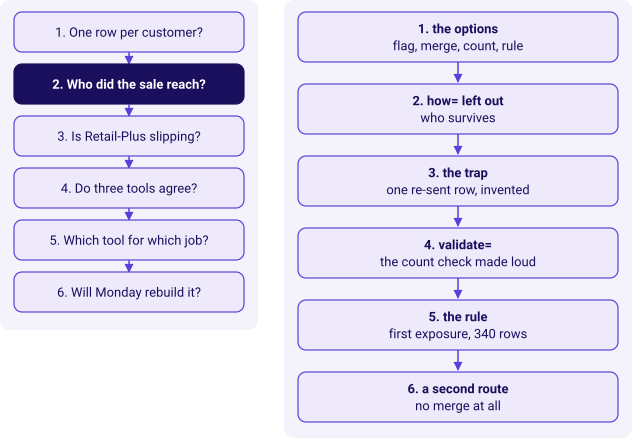

In [2]:
kit.side_by_side(
    kit.ladder(["One row per customer?", "Who did the sale reach?", "Is Retail-Plus slipping?", "Do three tools agree?", "Which tool for which job?", "Will Monday rebuild it?"], lit=1, show=False),
    kit.vflow(["1. the options\nflag, merge, count, rule", "2. how= left out\nwho survives", "3. the trap\none re-sent row, invented", "4. validate=\nthe count check made loud", "5. the rule\nfirst exposure, 340 rows", "6. a second route\nno merge at all"], show=False),
)

## 1. Which of four ways should attach the sale to the table, and what does each risk?

The feed names the Retail-Core and Retail-Plus customers the sale reached. Four ways a team
could put it on the table:

| Option | How it works | Keeps the date the sale reached them |
|---|---|---|
| a) A yes-or-no flag | `isin` marks each customer whose id appears anywhere in the feed | No |
| b) A plain merge | `merge(how="left")` on `customer_id` adds the feed's columns to each customer's row | Yes |
| c) A merge, counted | The same merge, with the rows counted before and after, Tuesday's habit | Yes |
| d) A rule, then a guarded merge | Keep one feed row per customer, the first date, then merge with `validate="one_to_one"`, which refuses to run if a customer appears twice | Yes |

What separates them is what happens when the platform sends a customer twice: a flag is set
once whatever the feed repeats, a plain merge gives that customer a second row, and so a second
copy of their spend. The next cell sizes that risk on the table's own customers.

option,rows out,spend overstated per re-sent row,the problem shows,keeps the date
a) a yes-or-no flag,"340, always",Rs 0,never,no
b) a plain merge,340 plus one per re-sent row,"Rs 5,100 to Rs 26,020",never,yes
"c) a merge, counted",340 plus one per re-sent row,"Rs 5,100 to Rs 26,020",after the table exists,yes
d) a rule and a guarded merge,"340, or the run stops",Rs 0,before the table exists,yes


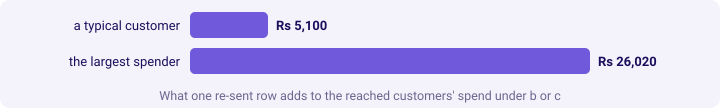

In [3]:
consumer = table[table["segment"].isin(["Retail-Core", "Retail-Plus"])]
typical, largest = consumer["spend"].median(), consumer["spend"].max()
sizing = [("a) a yes-or-no flag", "340, always", "Rs 0", "never", "no"),
          ("b) a plain merge", "340 plus one per re-sent row", f"{kit.rupees(typical)} to {kit.rupees(largest)}", "never", "yes"),
          ("c) a merge, counted", "340 plus one per re-sent row", f"{kit.rupees(typical)} to {kit.rupees(largest)}", "after the table exists", "yes"),
          ("d) a rule and a guarded merge", "340, or the run stops", "Rs 0", "before the table exists", "yes")]
kit.table(["option", "rows out", "spend overstated per re-sent row", "the problem shows", "keeps the date"],
          sizing, caption="Each option sized on the 270 Retail-Core and Retail-Plus customers the feed can name")
kit.bars([("a typical customer", typical), ("the largest spender", largest)], fmt=kit.rupees,
          title="What one re-sent row adds to the reached customers' spend under b or c")

**The best-fit call: d, the rule and the guarded merge.** The marketing lead's case for November
needs the date the sale reached each customer as well as the flag, because the next question is
whether they bought after it, and a feed that breaks the one-row rule should stop Monday's run
rather than inflate it. **The fact that would change it:** a table that only ever needs yes or
no. Then a, the flag, is simpler, cannot multiply a row and needs no rule.

## 2. Which customers does a merge keep when `how` is left out?

A merge is a join, with the same four shapes Tuesday drew in SQL.

| SQL, Tuesday | pandas, today | What survives |
|---|---|---|
| `INNER JOIN` | `merge(how="inner")` | Only keys found on both sides |
| `LEFT JOIN` | `merge(how="left")` | Every row of the left table |
| `RIGHT JOIN` | `merge(how="right")` | Every row of the right table |
| `FULL OUTER JOIN` | `merge(how="outer")` | Every key from either side |

The customer table is the spine, so the merge the growth team needs is left: every customer
stays, and the feed adds a date where it has one.

**Predict before you run.** `merge` with no `how` keeps which customers? a) every customer on
the table; b) only the customers the feed names, since the default is inner; c) every row of
the feed, even customers the table does not know; d) none, because `how` is required.

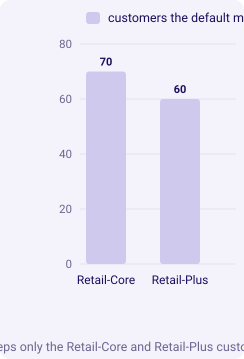

In [4]:
inner = table.merge(exposure, on="customer_id")           # how= left out
kept = inner["customer_id"].nunique()
named = inner.drop_duplicates("customer_id").groupby("segment").size()
kit.columns(named.index.tolist(), [("customers the default merge keeps", named.tolist())],
            title="The default merge keeps only the Retail-Core and Retail-Plus customers the feed names")
kit.check("the default merge keeps only customers the feed names",
          kept == exposure["customer_id"].nunique(), f"{kept} of {len(table)} customers")
kit.check("every customer the feed names is on the table", exposure["customer_id"].isin(table["customer_id"]).all())

**What happened.** The answer is b. `merge` defaults to an inner join, so it drops every
customer the sale did not reach, 210 of the 340, and the unreached are exactly the comparison
the marketing lead's case needs. Write `how=` on every merge, so the reader of the code knows
which rows survive.

## 3. What does one re-sent row do to the reached customers' spend?

The campaign platform sends its feed in batches, and a batch sent again brings its customers
twice. The mechanism shows best on a handful of rows. **These four customers and their feed are
invented for the mechanism; they are not Kalpa's.**

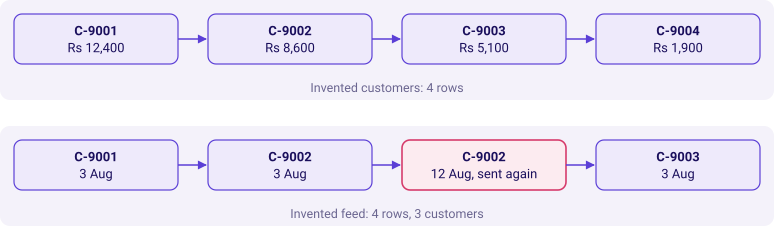

In [5]:
# Invented customers and an invented feed, to show the mechanism. They are not Kalpa's.
small = pd.DataFrame({"customer_id": ["C-9001", "C-9002", "C-9003", "C-9004"],
                      "segment": ["Retail-Plus", "Retail-Core", "Retail-Plus", "Student"],
                      "spend": [12400, 8600, 5100, 1900]})
small_feed = pd.DataFrame({"customer_id": ["C-9001", "C-9002", "C-9002", "C-9003"],
                           "exposed_date": pd.to_datetime(["2026-08-03", "2026-08-03",
                                                           "2026-08-12", "2026-08-03"])})

kit.side_by_side(
    kit.flow(["C-9001\nRs 12,400", "C-9002\nRs 8,600", "C-9003\nRs 5,100", "C-9004\nRs 1,900"],
             title="Invented customers: 4 rows", show=False),
    kit.flow(["C-9001\n3 Aug", "C-9002\n3 Aug", "C-9002\n12 Aug, sent again", "C-9003\n3 Aug"],
             kinds=[None, None, "bad", None], title="Invented feed: 4 rows, 3 customers", show=False),
)

**The plausible wrong answer.** The analyst merges, keeps the customers the sale reached, and
sums their spend for the marketing lead's slide.

**Predict before you run.** What does the slide say the reached customers spent?
a) Rs 26,100; b) Rs 28,000; c) Rs 34,700; d) Rs 17,200.

In [6]:
naive = small.merge(small_feed, on="customer_id", how="left")
wrong_spend = int(naive.loc[naive["exposed_date"].notna(), "spend"].sum())
kit.table(["customer_id", "spend", "exposed_date"],
          [(r.customer_id, kit.rupees(r.spend), "" if pd.isna(r.exposed_date) else str(r.exposed_date.date()))
           for r in naive.itertuples()], caption=f"{len(small)} customers in, {len(naive)} rows out")
kit.stats([(kit.rupees(wrong_spend), "spend of reached customers", "what the slide would say"),
           (len(naive), "rows after the merge", "from 4 customers")])

customer_id,spend,exposed_date
C-9001,"Rs 12,400",2026-08-03
C-9002,"Rs 8,600",2026-08-03
C-9002,"Rs 8,600",2026-08-12
C-9003,"Rs 5,100",2026-08-03
C-9004,"Rs 1,900",


**What happened.** The answer is c, Rs 34,700.

**Why it is wrong.** C-9002 appears twice in the feed, so the merge gives C-9002 two rows and
the sum counts its Rs 8,600 twice. Every row looks right on its own, which is why reading the
table never catches it. The slide overstates what the reached customers spent by a third, and
the case for November rests on money nobody paid. The check that catches it is Tuesday's: four
customers went in and five rows came out.

In [7]:
right_spend = int(small.loc[small["customer_id"].isin(small_feed["customer_id"]), "spend"].sum())
kit.check("the count check: rows grew from 4 to 5", len(small) == 4 and len(naive) == 5)
kit.check("the reached customers truly spent Rs 26,100", right_spend == 26100, kit.rupees(right_spend))
kit.check("the slide's excess is exactly C-9002's spend", wrong_spend - right_spend == 8600)

## 4. Which argument stops the merge before a wrong table exists?

The count check reports the problem after the wrong table exists. `validate` states what the
merge promises and raises an error the moment the data breaks the promise, before any table is
built. `"one_to_one"` promises each key once on both sides, `"many_to_one"` allows repeats on
the left but none on the right, and `"one_to_many"` the reverse.

**Predict before you run.** Which argument stops the invented merge? a) `how="left"`;
b) `validate="one_to_one"`; c) `indicator=True`; d) `sort=True`.

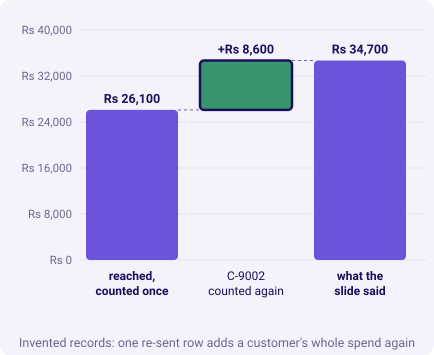

In [8]:
with kit.expect_error() as err:
    small.merge(small_feed, on="customer_id", how="left", validate="one_to_one")
kit.bridge(("reached, counted once", right_spend), [("C-9002 counted again", wrong_spend - right_spend)],
           end_label="what the slide said", lit=(0,),
           title="Invented records: one re-sent row adds a customer's whole spend again")
kit.check("validate='one_to_one' raises pandas.errors.MergeError", err.name == "MergeError",
          err.message.splitlines()[0])
kit.check("the error names the right-hand side, the feed", "not unique in right dataset" in err.message)

**What happened.** The answer is b. The merge stops with `pandas.errors.MergeError`, whose first
line reads *Merge keys are not unique in right dataset; not a one-to-one merge*; pandas 3.0.6
then lists the repeated keys beneath it. It is the row-count check made loud: nothing wrong is
built, so nothing wrong can be sent.

**Your turn, on Kalpa's feed, five minutes.** Type these lines into the empty cell and read each
answer aloud before you run the next.

```python
len(exposure), exposure["customer_id"].nunique()
len(table), len(table.merge(exposure, on="customer_id", how="left"))
table.merge(exposure, on="customer_id", how="left", validate="one_to_one")
```

Then say, in one sentence to the marketing lead, what a plain merge would have done to the
reached customers' spend, and by how many rupees.

## 5. Which exposure should a customer keep, and does the table stay at 340 rows?

A repeated customer is a business question before it is a pandas one: a customer the sale
reached twice was still reached. The rule for this table is one row per customer, the date the
sale first reached them. Sort the feed by date, keep each customer's first row, and merge with
`validate="one_to_one"`, so a feed that ever breaks the rule stops Monday's refresh instead of
inflating it.

**Predict before you run.** After sorting by date, which argument keeps each customer's first
exposure? a) `keep="last"`; b) `keep=False`; c) `keep="first"`; d) none, since the merge
ignores repeats.

In [9]:
first_touch = (exposure.sort_values("exposed_date")
                       .drop_duplicates("customer_id", keep="first")[["customer_id", "exposed_date"]])
with kit.expect_error() as clean:
    merged = table.merge(first_touch, on="customer_id", how="left", validate="one_to_one")
merged = merged.assign(reached=merged["exposed_date"].notna())
kit.check("the guarded merge runs once the rule is applied", clean.name is None)
kit.check("340 rows in, 340 rows out", len(merged) == len(table) == 340)
kit.check("spend did not move: Rs 19,84,00,000 before and after",
          merged["spend"].sum() == table["spend"].sum(), kit.rupees(merged["spend"].sum()))
kit.check("every customer the feed names is marked reached, once",
          int(merged["reached"].sum()) == exposure["customer_id"].nunique(), int(merged["reached"].sum()))

**What happened.** The answer is c. `keep="last"` would keep a later date wherever a customer
repeats, and `keep=False` drops every copy of a repeated customer, so a customer the platform
sent twice would read as never reached. The table stays at 340 rows, spend stays at
Rs 19,84,00,000, and 130 customers carry the date the sale first reached them.

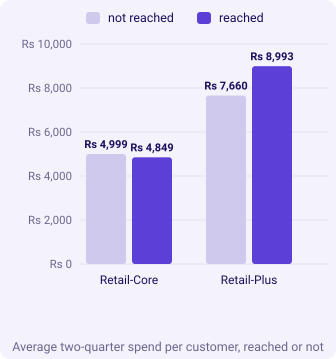

In [10]:
reached = merged[merged["reached"]]
per_seg = merged.groupby("segment")["reached"].sum().astype(int)
kit.stats([(int(merged["reached"].sum()), "customers reached", "one row each"),
           (kit.rupees(reached["spend"].sum()), "their spend", "two quarters, at the prices charged"),
           (int((~merged["reached"]).sum()), "not reached", "the comparison group")])
cons = merged[merged["segment"].isin(["Retail-Core", "Retail-Plus"])]
avg = cons.groupby(["segment", "reached"])["spend"].mean().unstack()
kit.columns(avg.index.tolist(), [("not reached", avg[False].round(0).tolist()),
                                 ("reached", avg[True].round(0).tolist())], fmt=kit.rupees,
            title="Average two-quarter spend per customer, reached or not")

**What the chart does not say.** Reached Retail-Plus customers spent more on average than the
members the sale missed, and reached Retail-Core customers a little less. Week 1 Thursday found
that the customers the monsoon sale reached skewed towards those who were buying anyway, so an
average among the reached says who was chosen before it says what the sale did. The table
records whom the sale reached; whether it changed their spending is a separate question with a
separate test.

> **Kavya's review.** "A merge is a join, so I want Tuesday's two numbers before this table goes
> to Marketing: 340 rows in and 340 out, and Rs 19,84,00,000 before and after. A merge that
> moves either is wrong until you can say why, and the rule you chose goes in writing beside
> the table."

## 6. Does a count with no merge at all give the same reach and spend?

The reach and the reached spend came from a sorted feed, a rule and a merge. Two routes share
none of that code. `isin` marks each customer whose id appears anywhere in the feed, and a flag
cannot multiply a row. The warehouse keeps its own copy of the feed, `campaign_exposure`: it
counts the distinct customers in it, and it sums the orders of customers `IN` it, and `IN` only
asks whether a customer is there, however often.

route,customers reached,their spend
the rule and the merge,130,"Rs 8,78,980"
the isin flag,130,"Rs 8,78,980"
SQL in the warehouse,130,"Rs 8,78,980"


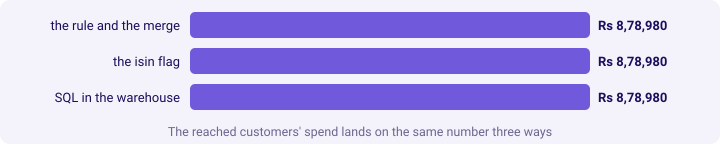

In [11]:
flag = table["customer_id"].isin(exposure["customer_id"])
REACHED = """SELECT count(DISTINCT customer_id) AS reached
FROM   campaign_exposure;"""
SPEND = """SELECT sum(amount) AS reached_spend
FROM   orders
WHERE  customer_id IN (SELECT customer_id FROM campaign_exposure);"""
sql_reached = int(kit.sql(REACHED)[0]["reached"])
sql_spend = float(kit.sql(SPEND)[0]["reached_spend"])
routes = [("the rule and the merge", int(merged["reached"].sum()), float(reached["spend"].sum())),
          ("the isin flag", int(flag.sum()), float(table.loc[flag, "spend"].sum())),
          ("SQL in the warehouse", sql_reached, sql_spend)]
kit.table(["route", "customers reached", "their spend"],
          [(name, n, kit.rupees(s)) for name, n, s in routes], caption="Reach and spend, three ways")
kit.bars([(name, s) for name, _, s in routes], fmt=kit.rupees,
         title="The reached customers' spend lands on the same number three ways")

In [12]:
kit.check("the flag and the merge reach the same 130 customers", routes[0][1] == routes[1][1] == 130)
kit.check("SQL reaches the same customers", sql_reached == routes[0][1])
kit.check("all three routes agree on the reached customers' spend",
          routes[0][2] == routes[1][2] == routes[2][2], kit.rupees(routes[0][2]))

**When to switch.** The rule and the guarded merge are the route for the table, because the
date rides along with the customer. `isin` is the route whenever the question is only yes or
no. The SQL is the route for anyone who wants the number without the notebook, such as Finance
checking the marketing lead's slide.

### How would you answer this chapter's questions in an interview?

**[S] Merge against join: what is the same and what differs?** "The same: both match rows on a
key, both come in inner, left, right and outer, and both multiply rows when a key repeats on
the side you did not expect. The differences: pandas defaults to inner, so I always write
`how=`; pandas runs in memory on data I have already pulled, where the warehouse joins where
the data lives; and pandas can refuse the wrong shape with `validate=`, which SQL has no single
argument for."

**[F] Which merge argument raises on duplicate keys, and which error does it raise?**
"`validate`, set to `one_to_one`, `one_to_many` or `many_to_one`. When the keys break the
promise it raises `pandas.errors.MergeError`, naming the side whose keys are not unique. It is
the row-count check made loud: it stops the table being built instead of reporting afterwards."

**[F] Your Monday refresh stopped with a `MergeError`. What do you do?** "I do not delete the
repeats to make it pass. I read the repeated keys, find out why the source sent them, apply a
business rule, here the first exposure per customer, and keep `validate` on so the next
surprise also stops the run. Then I tell the owner of the feed."

### Going deeper: how does pandas list the customers on one side only, the way Tuesday's anti-join did?

Tuesday's anti-join, rows on one side with no match on the other, is one argument in pandas:
`indicator=True` adds a `_merge` column saying where each row came from.

In [13]:
sides = table.merge(first_touch, on="customer_id", how="outer", indicator=True, validate="one_to_one")
counts = sides["_merge"].value_counts()
kit.table(["_merge", "customers", "reads as"],
          [("both", int(counts.get("both", 0)), "on the list, and reached"),
           ("left_only", int(counts.get("left_only", 0)), "on the list, never reached"),
           ("right_only", int(counts.get("right_only", 0)), "in the feed, unknown to the list")],
          caption="indicator=True on an outer merge of the list and the first-touch feed")
kit.check("no customer in the feed is unknown to the warehouse", int(counts.get("right_only", 0)) == 0)

_merge,customers,reads as
both,130,"on the list, and reached"
left_only,210,"on the list, never reached"
right_only,0,"in the feed, unknown to the list"


**The answers, question by question.**

1. The rule and a guarded merge attach the sale: it keeps the date and stops on a repeat, where
   a plain merge overstates spend by a customer's whole spend for every re-sent row.
2. With `how` left out, the merge keeps only the 130 customers the feed names and drops the 210
   the sale missed.
3. One re-sent row made the invented slide say Rs 34,700 where the reached customers spent
   Rs 26,100.
4. `validate="one_to_one"` stops the merge with a `MergeError` before a wrong table exists.
5. Each customer keeps their first exposure; the table stays at 340 rows and Rs 19,84,00,000,
   with 130 customers reached.
6. The flag, the merge and the warehouse agree: 130 customers reached, who spent Rs 8,78,980.

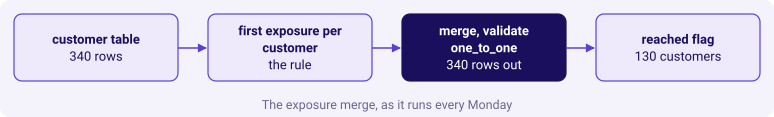

Next: chapter 3 turns the orders into months, for the head of Retail-Plus.


In [14]:
kit.flow(["customer table\n340 rows", "first exposure per customer\nthe rule",
          "merge, validate one_to_one\n340 rows out", "reached flag\n130 customers"], lit=2,
         title="The exposure merge, as it runs every Monday")
kit.check_summary()
print("Next: chapter 3 turns the orders into months, for the head of Retail-Plus.")